# Representation is not the same as policy consequences

An election can look reasonable when it is judged only by where the winning position sits in space, yet look quite different once that position is interpreted as a policy with uneven consequences. This notebook keeps the electoral outcomes fixed and changes the way policy utility is defined.

The notebook works through three hand-built cases. In each case it compares the same set of electoral systems under three utility models, then ends with a short takeaway based on the simulated results.

In [1]:
from pathlib import Path
import sys

import importlib
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import notebooks.helpers.representation_vs_policy_consequences as rp

importlib.reload(rp)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 3)

BASE_SEED = 7
N_VOTERS = 1800

## Preliminaries

The notebook starts from a familiar spatial idea. Each voter has an ideal point $x_i$ in a two-dimensional policy space, and each electoral system produces an outcome that is then interpreted as a policy vector $p$.

There are two ways to judge that outcome.

The first is the representation view. A simple representation welfare summary is the negative average distance from voters to the realized outcome,

$$
W_{\text{rep}}(p) = -\frac{1}{n}\sum_{i=1}^n \lVert x_i - p \rVert.
$$

This asks a geometric question: how close is the outcome to where people are located in the map?

The second is the policy-consequence view. Here the same point $p$ is treated as an actual policy, and voters may care about more than raw geometric closeness. That is the main focus of the notebook.

Three utility models are used.

`Distance-only` is the plainest benchmark:

$$
u_i^{\text{dist}}(p) = -\lVert x_i - p \rVert.
$$

It says that policies are good when they are spatially close to a voter's ideal point.

`Exposure-sensitive` adds the idea that the same policy can affect different groups differently. In the implementation, redistribution and public goods matter with different weights for the majority and minority blocs, so utility has the form

$$
u_i^{\text{exp}}(p) = -d_i^{(w)}(p) + a_{g(i)}\,p_{\text{public}} + b_{g(i)}\,(p_{\text{redist}} - 0.5),
$$

where $g(i)$ is voter $i$'s group. The point is not that this is the one correct welfare model. The point is that once policy is made explicit, equal-looking representation outcomes can imply unequal consequences.

`Threshold-sensitive` goes one step further. It keeps the exposure-sensitive model, but adds a floor effect on redistribution. Below a group-specific threshold $\bar r_g$, a policy is treated as substantially worse than ordinary distance alone would suggest:

$$
u_i^{\text{thr}}(p) = u_i^{\text{exp}}(p) + T_{g(i)}(p_{\text{redist}}).
$$

where $T_{g(i)}$ applies a penalty when $p_{\text{redist}} < \bar r_{g(i)}$.

When reading the results, higher aggregate utility is better, higher minority utility is better, and a smaller majority-minority gap means the policy consequences are being shared more evenly across the two groups.

## Cases and systems

#### Cases

The notebook uses three hand-built cases.

`Overlapping blocs` is the calmest setting. The majority and minority groups live in broadly the same part of the policy space, and the candidate slate includes a clear middle option. This is the case where one should expect many systems to converge on roughly the same answer.

`Moderate burden shift` keeps a moderate majority, but places the minority farther away and makes that minority more sensitive to redistribution and public-goods choices. This is the case where a result can still look fairly reasonable in geometric terms while carrying very different welfare consequences for the smaller group.

`Fragmented legislature` spreads the candidate slate out more. The electorate is still two-group, but there are more viable coalition-like compromises in the slate. This is where systems that reward broader support have more room to distinguish themselves from simpler winner-take-all rules.

#### Systems

The electoral systems are also intentionally simple to describe.

`Plurality` asks each voter to choose one candidate, and the top vote-getter wins.

`IRV` lets voters rank candidates and then eliminates the weakest candidate until one candidate remains.

`Approval` allows voters to support every candidate they find acceptable, with the most approvals winning.

`Score` asks voters to score each candidate, and the highest average score wins.

`Condorcet` looks for the candidate who can beat every rival head-to-head.

`Fractional discrete (sigma = 1.0)` asks each voter to spread support across candidates using a distance-weighted rule,

$$
w_{ik} = \frac{e^{-d_{ik}/\sigma}}{\sum_j e^{-d_{ij}/\sigma}}, \qquad \sigma = 1.0,
$$

then converts the average weight vector into a single winner by finding the candidate nearest the resulting centroid.

`Fractional continuous (sigma = 1.0)` uses the same fractional support rule, but does not snap back to a single winner. Instead, the policy outcome is the weighted combination of candidate positions implied by the average support weights.

`Party-list PR` is the only proportional system in the notebook in the usual party-list sense. Instead of reducing the election to a single winner, it produces a legislature-like outcome and then summarizes that outcome as a policy position.

The aim is not to declare a universal winner. It is to see when different electoral systems produce genuinely different policies, when fractional aggregation behaves like a bridge between winner-take-all and proportional outcomes, and when the bigger story comes from how those policies translate into consequences for different voters.

In [2]:
case_results = {
    case_name: rp.compare_consequence_models(
        case_name=case_name,
        seed=BASE_SEED,
        n_voters=N_VOTERS,
    )
    for case_name in rp.CASE_ORDER
}

all_results = pd.concat([case_results[case_name] for case_name in rp.CASE_ORDER], ignore_index=True)

## Overlapping blocs

This is the gentlest case in the notebook. The two groups overlap a lot, and the candidate slate places several options near the middle. The natural question is whether the electoral rule still matters much once the policy layer is added, or whether all of the interesting movement comes from how utility is defined.

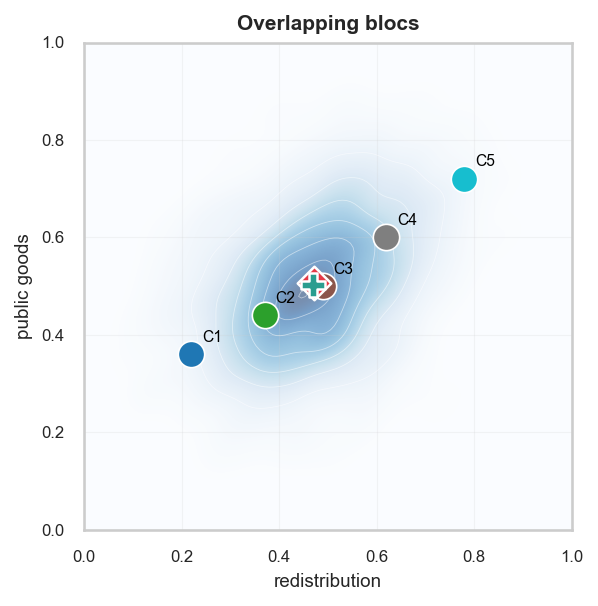

In [3]:
rp.plot_case_gallery(case_names=["Overlapping blocs"], seed=BASE_SEED, n_voters=N_VOTERS);

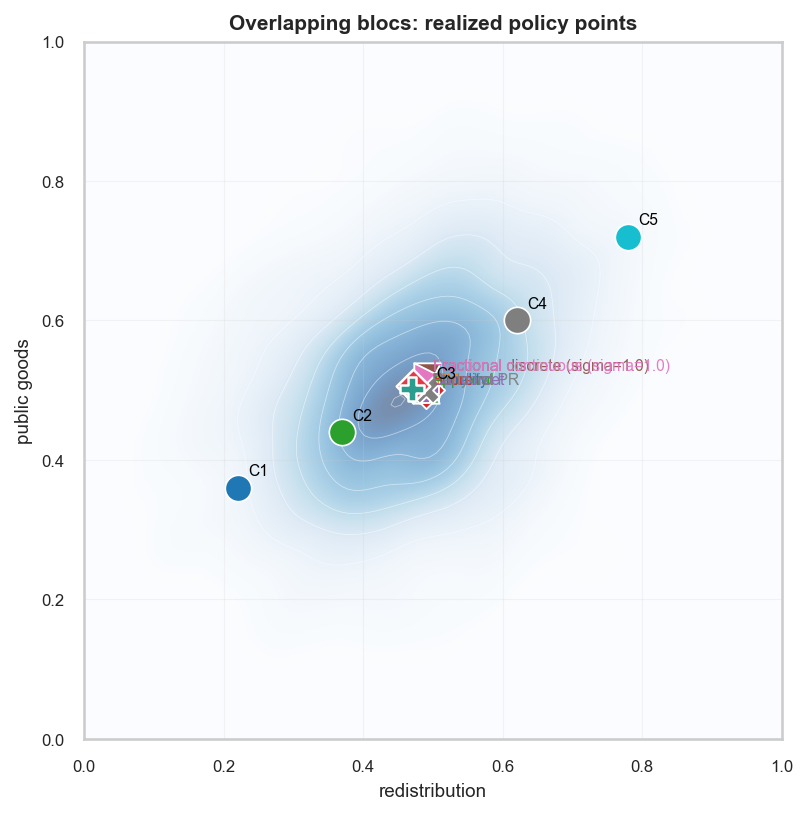

In [4]:
rp.plot_case_policy_points(case_results["Overlapping blocs"], "Overlapping blocs", seed=BASE_SEED, n_voters=N_VOTERS);

In [5]:
display(rp.case_comparison_table(case_results["Overlapping blocs"], "Overlapping blocs"))

Aggregate utility  \
                                                         Distance-only   
system                            winner                                 
Plurality                         C3                            -0.157   
IRV                               C3                            -0.157   
Approval                          C3                            -0.157   
Score                             C3                            -0.157   
Condorcet                         C3                            -0.157   
Fractional discrete (sigma=1.0)   C3                            -0.158   
Fractional continuous (sigma=1.0) C3, C2, C4, C1, C5            -0.158   
Party-list PR                     C3, C2, C4, C1, C5            -0.157   

                                                                         \
                                                     Exposure-sensitive   
system                            winner                                  
Plurality                         C3                              0.037   
IRV                               C3                              0.037   
Approval                          C3                              0.037   
Score                             C3                              0.037   
Condorcet                         C3                              0.037   
Fractional discrete (sigma=1.0)   C3                              0.043   
Fractional continuous (sigma=1.0) C3, C2, C4, C1, C5              0.043   
Party-list PR                     C3, C2, C4, C1, C5              0.037   

                                                                          \
                                                     Threshold-sensitive   
system                            winner                                   
Plurality                         C3                              -0.090   
IRV                               C3                              -0.090   
Approval                          C3                              -0.090   
Score                             C3                              -0.090   
Condorcet                         C3                              -0.090   
Fractional discrete (sigma=1.0)   C3                              -0.086   
Fractional continuous (sigma=1.0) C3, C2, C4, C1, C5              -0.086   
Party-list PR                     C3, C2, C4, C1, C5              -0.090   

                                                     Majority-minority gap  \
                                                             Distance-only   
system                            winner                                     
Plurality                         C3                                 0.034   
IRV                               C3                                 0.034   
Approval                          C3                                 0.034   
Score                             C3                                 0.034   
Condorcet                         C3                                 0.034   
Fractional discrete (sigma=1.0)   C3                                 0.017   
Fractional continuous (sigma=1.0) C3, C2, C4, C1, C5                 0.017   
Party-list PR                     C3, C2, C4, C1, C5                 0.034   

                                                                         \
                                                     Exposure-sensitive   
system                            winner                                  
Plurality                         C3                             -0.115   
IRV                               C3                             -0.115   
Approval                          C3                             -0.115   
Score                             C3                             -0.115   
Condorcet                         C3                             -0.115   
Fractional discrete (sigma=1.0)   C3                             -0.135   
Fractional continuous (sigma=1.0) C3, C2,

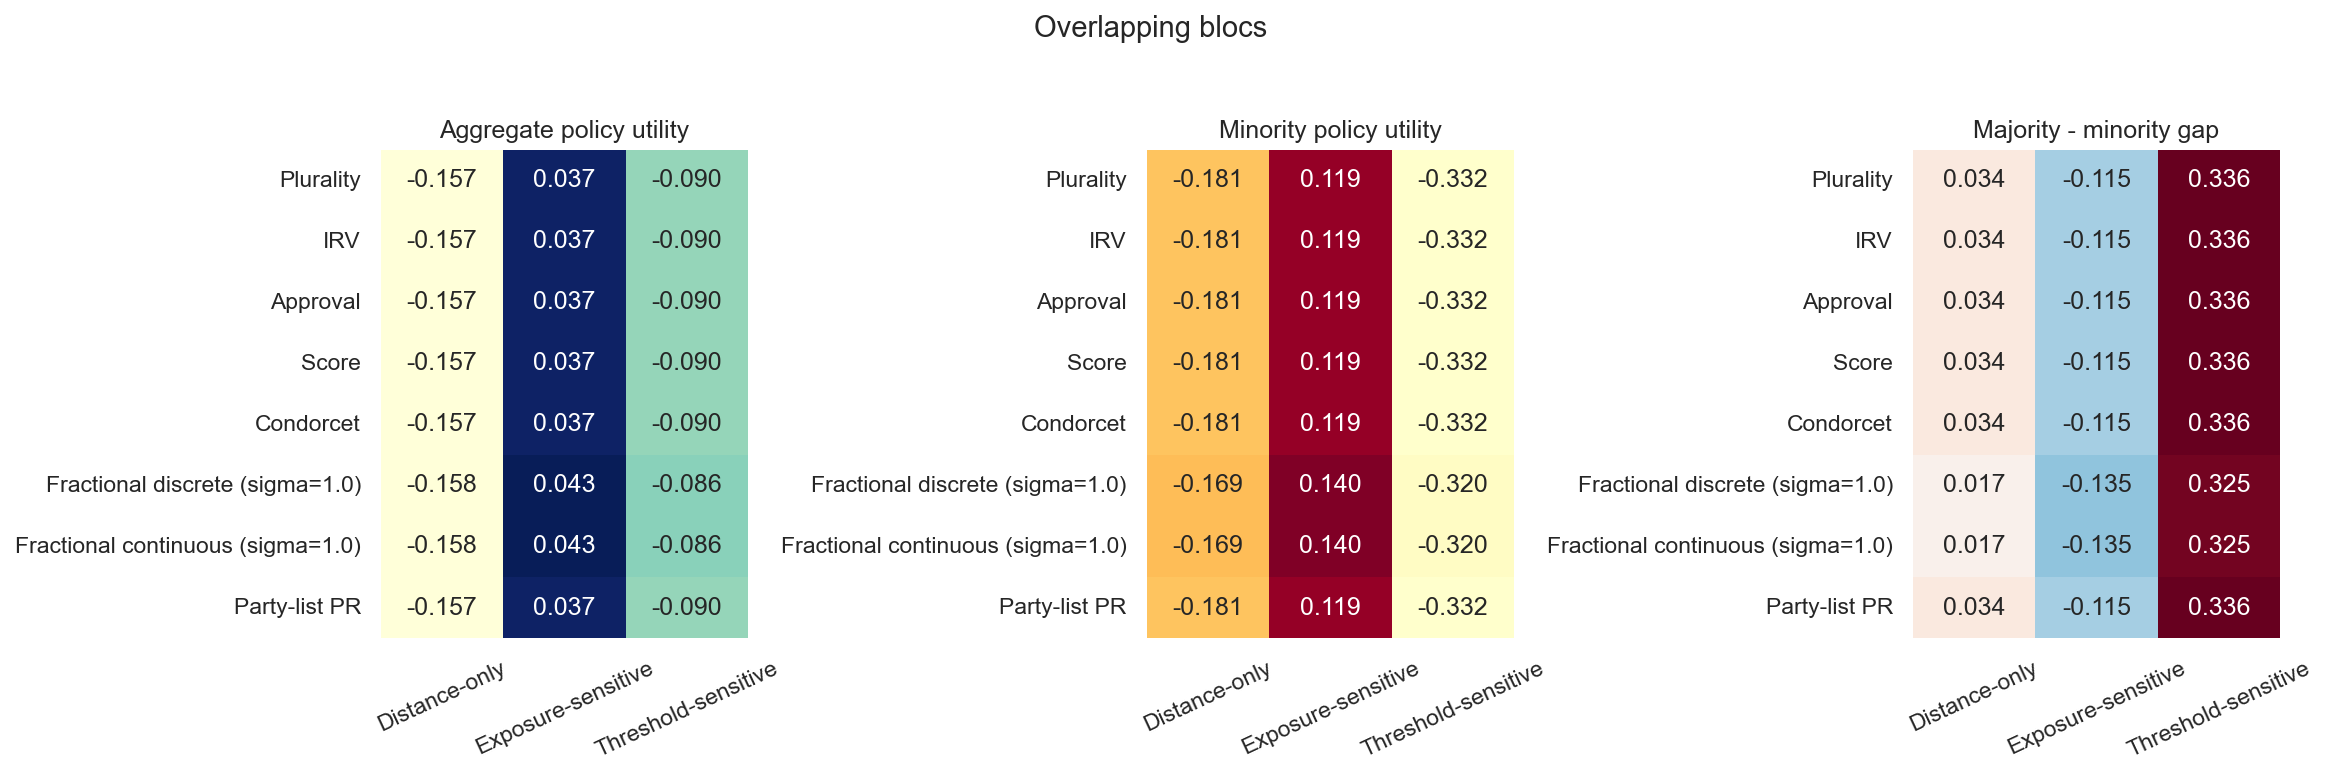

In [6]:
rp.plot_case_model_heatmaps(case_results["Overlapping blocs"], "Overlapping blocs");

### Takeaway

In this case, the main story is convergence. The classic systems all land on almost the same outcome, but the two fractional variants move just a little farther toward the middle. That small geometric shift is enough to make them the best performers under the exposure-sensitive model and slightly less harsh under the threshold-sensitive model. So even in a case where electoral rules mostly agree, fractional aggregation already starts to look like a mild bridge between the shared middle outcome and a more group-sensitive policy compromise.

## Moderate burden shift

Here the minority bloc is smaller and farther from the majority cluster, and the utility models treat that bloc as more exposed to redistribution and public-goods choices. This is the first case where it becomes plausible that a system can look decent in ordinary representation terms while still producing noticeably worse consequences for the more vulnerable group.

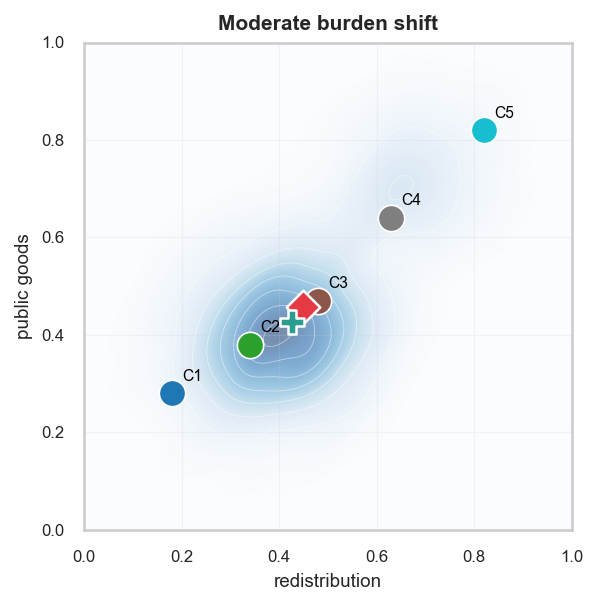

In [7]:
rp.plot_case_gallery(case_names=["Moderate burden shift"], seed=BASE_SEED, n_voters=N_VOTERS);

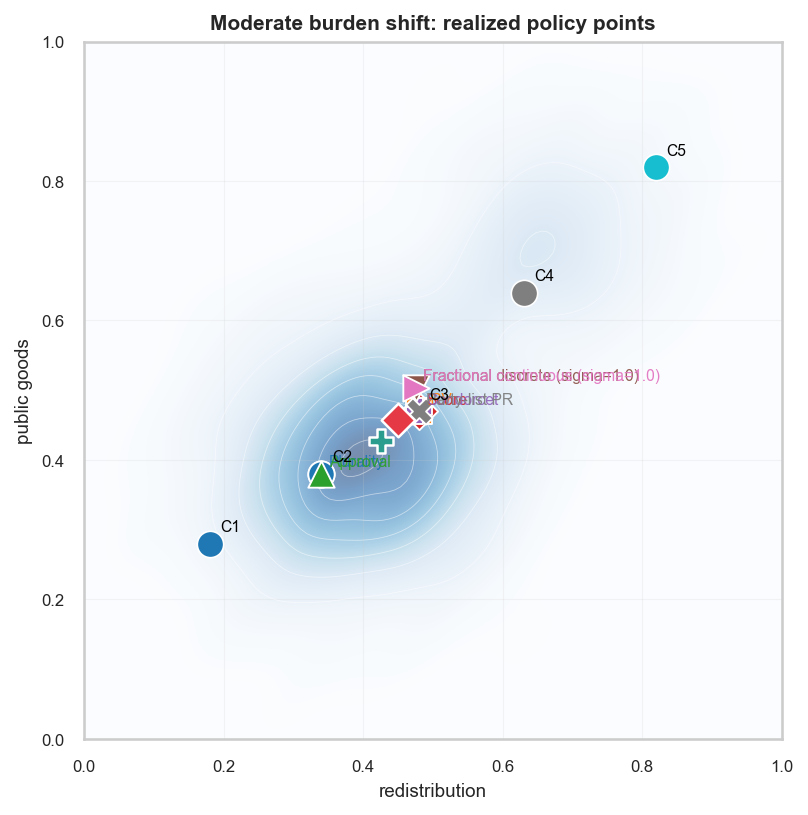

In [8]:
rp.plot_case_policy_points(case_results["Moderate burden shift"], "Moderate burden shift", seed=BASE_SEED, n_voters=N_VOTERS);

In [9]:
display(rp.case_comparison_table(case_results["Moderate burden shift"], "Moderate burden shift"))

Aggregate utility  \
                                                         Distance-only   
system                            winner                                 
Plurality                         C2                            -0.201   
IRV                               C3                            -0.188   
Approval                          C2                            -0.201   
Score                             C3                            -0.188   
Condorcet                         C3                            -0.188   
Fractional discrete (sigma=1.0)   C3                            -0.195   
Fractional continuous (sigma=1.0) C3, C2, C4, C1, C5            -0.195   
Party-list PR                     C2, C3, C4, C1, C5            -0.188   

                                                                         \
                                                     Exposure-sensitive   
system                            winner                                  
Plurality                         C2                             -0.046   
IRV                               C3                             -0.012   
Approval                          C2                             -0.046   
Score                             C3                             -0.012   
Condorcet                         C3                             -0.012   
Fractional discrete (sigma=1.0)   C3                             -0.007   
Fractional continuous (sigma=1.0) C3, C2, C4, C1, C5             -0.007   
Party-list PR                     C2, C3, C4, C1, C5             -0.012   

                                                                          \
                                                     Threshold-sensitive   
system                            winner                                   
Plurality                         C2                              -0.480   
IRV                               C3                              -0.072   
Approval                          C2                              -0.480   
Score                             C3                              -0.072   
Condorcet                         C3                              -0.072   
Fractional discrete (sigma=1.0)   C3                              -0.071   
Fractional continuous (sigma=1.0) C3, C2, C4, C1, C5              -0.071   
Party-list PR                     C2, C3, C4, C1, C5              -0.072   

                                                     Majority-minority gap  \
                                                             Distance-only   
system                            winner                                     
Plurality                         C2                                 0.338   
IRV                               C3                                 0.164   
Approval                          C2                                 0.338   
Score                             C3                                 0.164   
Condorcet                         C3                                 0.164   
Fractional discrete (sigma=1.0)   C3                                 0.128   
Fractional continuous (sigma=1.0) C3, C2, C4, C1, C5                 0.128   
Party-list PR                     C2, C3, C4, C1, C5                 0.164   

                                                                         \
                                                     Exposure-sensitive   
system                            winner                                  
Plurality                         C2                              0.298   
IRV                               C3                              0.010   
Approval                          C2                              0.298   
Score                             C3                              0.010   
Condorcet                         C3                              0.010   
Fractional discrete (sigma=1.0)   C3                             -0.025   
Fractional continuous (sigma=1.0) C3, C2,

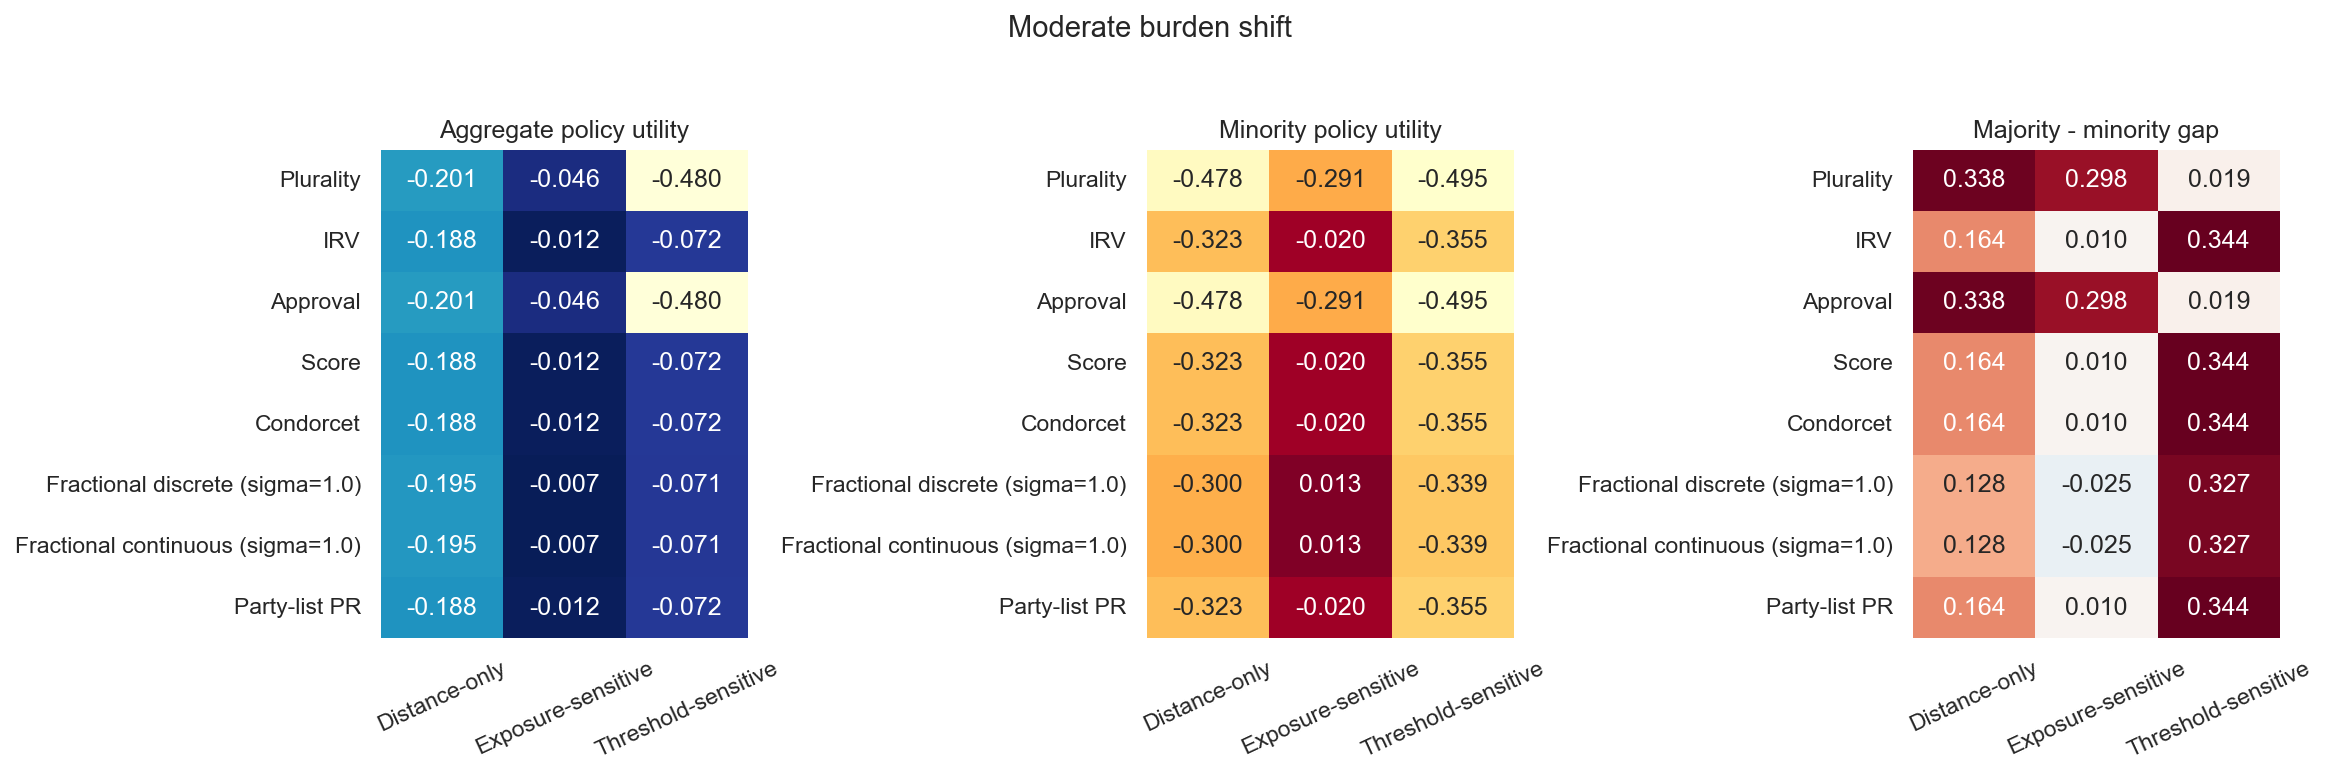

In [10]:
rp.plot_case_model_heatmaps(case_results["Moderate burden shift"], "Moderate burden shift");

### Takeaway

This is the first case where the systems separate clearly. Under the exposure-sensitive model, the strongest aggregate performers are the two fractional variants, which also turn the minority bloc's utility positive. IRV, Score, Condorcet, and Party-list PR still do much better than plurality and approval, but the fractional systems go one step further by improving minority utility while also shrinking the majority-minority gap. Once the redistribution floor is imposed, plurality takes by far the largest penalty, while the fractional systems and the broader-support rules all avoid most of that damage. In this case, fractional voting behaves like a compromise device that keeps some of the structure of single-winner politics while softening its harshest welfare consequences.

## Fragmented legislature

The last case keeps a two-group electorate but spreads the candidate slate out more. That makes compromise and coalition-friendly outcomes easier to imagine. The question here is whether systems that reward broader support convert that extra flexibility into better policy consequences, especially for the minority bloc.

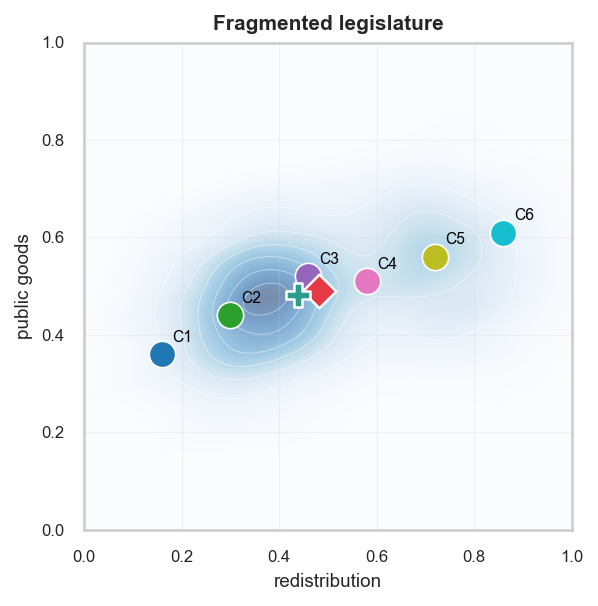

In [11]:
rp.plot_case_gallery(case_names=["Fragmented legislature"], seed=BASE_SEED, n_voters=N_VOTERS);

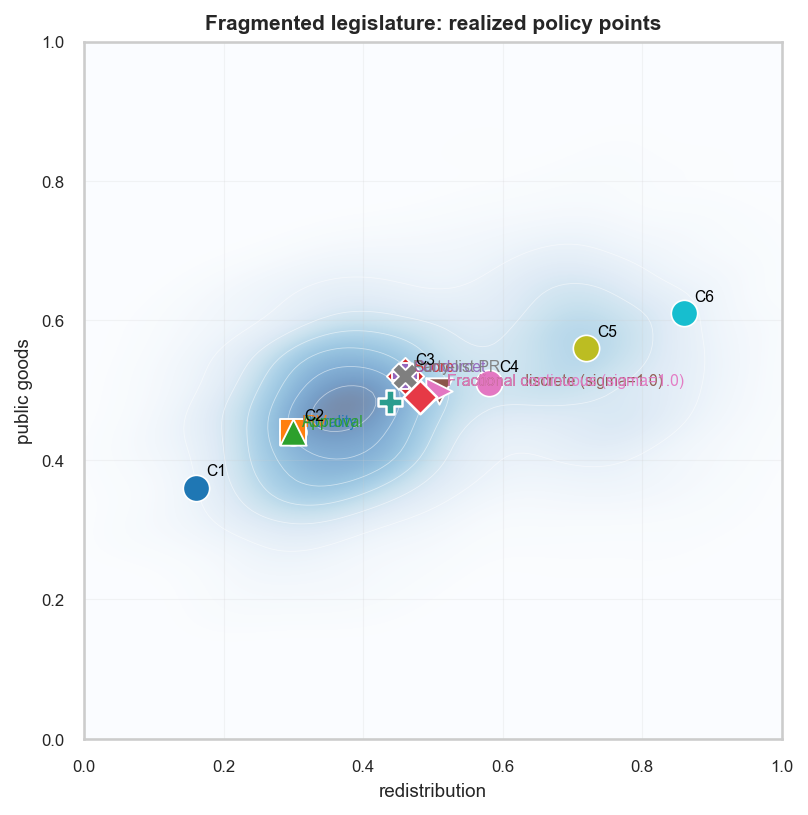

In [12]:
rp.plot_case_policy_points(case_results["Fragmented legislature"], "Fragmented legislature", seed=BASE_SEED, n_voters=N_VOTERS);

In [13]:
display(rp.case_comparison_table(case_results["Fragmented legislature"], "Fragmented legislature"))

Aggregate utility  \
                                                             Distance-only   
system                            winner                                     
Plurality                         C2                                -0.240   
IRV                               C2                                -0.240   
Approval                          C2                                -0.240   
Score                             C3                                -0.201   
Condorcet                         C3                                -0.201   
Fractional discrete (sigma=1.0)   C3                                -0.205   
Fractional continuous (sigma=1.0) C3, C4, C2, C5, C1, C6            -0.205   
Party-list PR                     C2, C3, C5, C4, C6, C1            -0.201   

                                                                             \
                                                         Exposure-sensitive   
system                            winner                                      
Plurality                         C2                                 -0.066   
IRV                               C2                                 -0.066   
Approval                          C2                                 -0.066   
Score                             C3                                  0.008   
Condorcet                         C3                                  0.008   
Fractional discrete (sigma=1.0)   C3                                  0.001   
Fractional continuous (sigma=1.0) C3, C4, C2, C5, C1, C6              0.001   
Party-list PR                     C2, C3, C5, C4, C6, C1              0.008   

                                                                              \
                                                         Threshold-sensitive   
system                            winner                                       
Plurality                         C2                                  -0.465   
IRV                               C2                                  -0.465   
Approval                          C2                                  -0.465   
Score                             C3                                  -0.105   
Condorcet                         C3                                  -0.105   
Fractional discrete (sigma=1.0)   C3                                  -0.123   
Fractional continuous (sigma=1.0) C3, C4, C2, C5, C1, C6              -0.123   
Party-list PR                     C2, C3, C5, C4, C6, C1              -0.105   

                                                         Majority-minority gap  \
                                                                 Distance-only   
system                            winner                                         
Plurality                         C2                                     0.318   
IRV                               C2                                     0.318   
Approval                          C2                                     0.318   
Score                             C3                                     0.133   
Condorcet                         C3                                     0.133   
Fractional discrete (sigma=1.0)   C3                                     0.068   
Fractional continuous (sigma=1.0) C3, C4, C2, C5, C1, C6                 0.068   
Party-list PR                     C2, C3, C5, C4, C6, C1                 0.133   

                                                                             \
                                                         Exposure-sensitive   
system                            winner                                      
Plurality                         C2                                  0.305   
IRV                               C2                                  0.305   
Approval                          C2                                  0.305   
Score                             C3                                 -

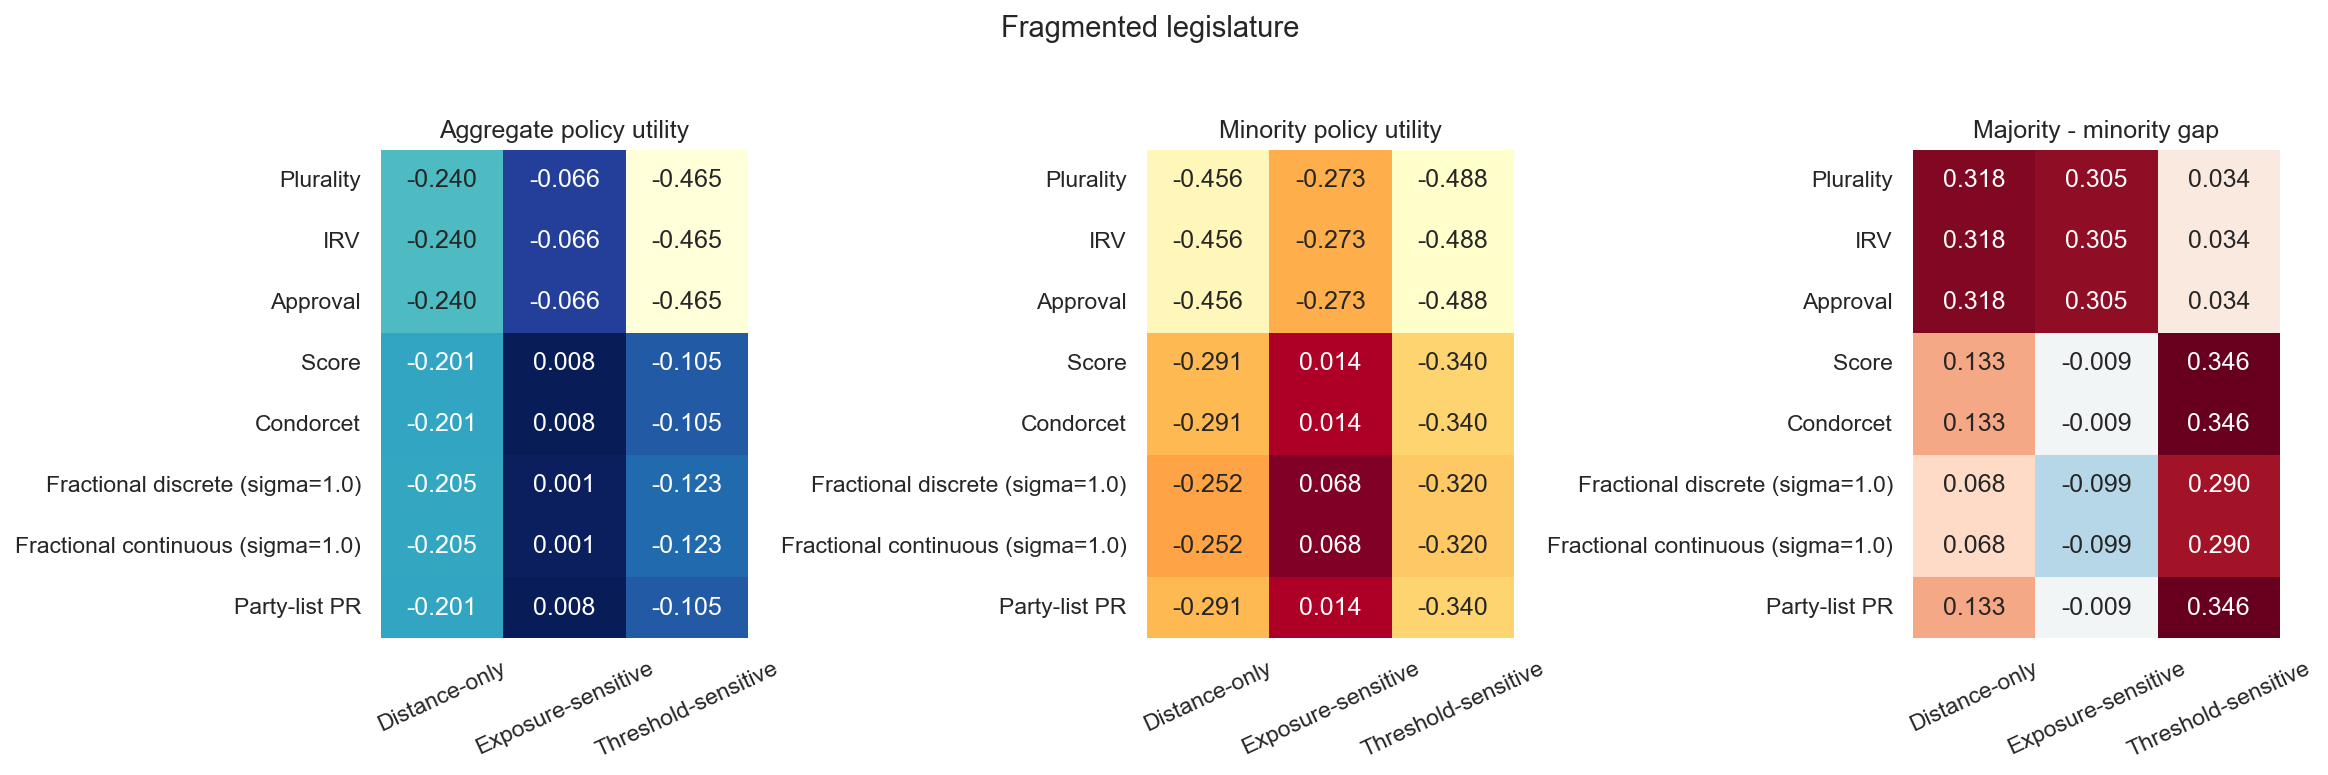

In [14]:
rp.plot_case_model_heatmaps(case_results["Fragmented legislature"], "Fragmented legislature");

### Takeaway

The fragmented slate makes the comparison more nuanced. Score, Condorcet, and Party-list PR remain the best systems on aggregate utility, but the two fractional variants are noticeably better than plurality, IRV, and approval on minority utility and on the majority-minority gap. In other words, the fractional systems are not the aggregate winners here, but they still move the outcome toward a more even sharing of policy consequences across groups. This case makes them look less like a universal replacement for broader-support rules and more like an intermediate option: better than simple winner-take-all outcomes, but not as strong as the best coalition-friendly systems when the slate offers several viable compromises.

## Conclusion

Across these three cases, Score, Condorcet, and Party-list PR are still the most consistent leaders on aggregate utility. But adding the fractional systems makes the comparison more interesting. The two fractional variants repeatedly outperform plurality and approval once policy consequences become group-sensitive, and in the moderate burden-shift case they are the strongest performers under the exposure-sensitive model.

